#Phase 5: Targeted Synthetic Data Augmentation

## Step 5.1: Empirically Determined Threshold (Learning Curve):

In [ ]:
import matplotlib.pyplot as plt                                                                                                                           
import pandas as pd                                                                                                                                       
import os                                                                                                                                                 
import warnings                                                                                                                                           
                                                                                                                                                            
from sklearn.feature_extraction.text import TfidfVectorizer                                                                                               
from sklearn.linear_model import LogisticRegression                                                                                                       
from sklearn.metrics import f1_score                                                                                                                      
from sklearn.pipeline import make_pipeline                                                                                                                
from sklearn.utils import resample                                                                                                                        
                                                                                                                                                            
warnings.filterwarnings('ignore')           

In [11]:
base_dir = 'D:/Ateneo de Davao/Thesis-Project-Aspect-Based-Sentiment-Analysis/_4_Strict_Data_Parititioning'
file_path = os.path.join(base_dir, 'Train_Set_70.csv')
#----
base_dir1 = 'D:/Ateneo de Davao/Thesis-Project-Aspect-Based-Sentiment-Analysis/_4_Strict_Data_Parititioning'
file_path1 = os.path.join(base_dir1, 'Validation_Set_15.csv')

df_train= pd.read_csv(file_path)
df_val= pd.read_csv(file_path1)

In [17]:
# Drop nulls just in case the explosion phase left empty sentences
df_train = df_train.dropna(subset=['sentence', 'TargetAspect']).copy()                                                                                    
df_val = df_val.dropna(subset=['sentence', 'TargetAspect']).copy()   

In [18]:
df_train

,place_name,rating,shop_type,sentence,TargetAspect,Sentiment,TargetClass
0,Coffeefolks Cafe,5,coffee,If you are looking for a place that you want t...,Product Quality,Positive,Product Quality - Positive
1,BRGR Alley Café,5,coffee,"delicious food, great service and very nice place",Customer Service,Positive,Customer Service - Positive
2,BRGR Alley Café,5,coffee,"The plating was good, the drinks, the ambiance...",Ambiance and Atmosphere,Positive,Ambiance and Atmosphere - Positive
3,Green Coffee - Marfori,4,coffee,"Place can cater a lot of people, they also hav...",Ambiance and Atmosphere,Positive,Ambiance and Atmosphere - Positive
4,REVEL by Confex,5,coffee,"Exceptional customer service, fantastic atmosp...",Product Quality,Positive,Product Quality - Positive
...,...,...,...,...,...,...,...
16135,PICKUP COFFEE - Gaisano Mall of Davao,5,coffee,"They offer tea and chocolate options, in addit...",Product Quality,Positive,Product Quality - Positive
16136,BRGR Alley Café,1,coffee,"To be fair, I didn't experience this during my...",Customer Service,Negative,Customer Service - Negative
16137,Coffeecat,5,coffee,Basil pesto pasta and cheesecakes are must try...,Price and Value,Positive,Price and Value - Positive
16138,Green Coffee - Diversion,4,coffee,If you like to chill and drink your coffee wit...,Product Quality,Positive,Product Quality - Positive


In [19]:
df_val

,place_name,rating,shop_type,sentence,TargetAspect,Sentiment,TargetClass
0,Starbucks,5,coffee,All baristas are very friendly.,Customer Service,Positive,Customer Service - Positive
1,Kafih - Davao,1,coffee,High Speed Internet was posted infront of the ...,Facilities and Amenities,Negative,Facilities and Amenities - Negative
2,Floury Cafe,3,matcha,Food was average and could definitely use impr...,Product Quality,Neutral,Product Quality - Neutral
3,Green Coffee - Diversion,4,coffee,"Overall, still a great café for the ambiance, ...",Customer Service,Positive,Customer Service - Positive
4,Habitat Coffee - Tulip Branch,2,coffee,₱179 pesos for a really small iced seasalt latte.,Product Quality,Negative,Product Quality - Negative
...,...,...,...,...,...,...,...
3454,sips sala,5,matcha,Their coffee is also delicious and now I'm obs...,Product Quality,Positive,Product Quality - Positive
3455,Whisk It Good Matcha,5,matcha,My wife's favorite matcha place in DVO smilin...,Customer Service,Positive,Customer Service - Positive
3456,Starbucks - SM City Davao,5,coffee,Consistently good service.,Customer Service,Positive,Customer Service - Positive
3457,Daleachious Cafe - Ecoland Branch,5,coffee,"Nothing fancy of elegant about this place, but...",Product Quality,Positive,Product Quality - Positive


In [23]:
def map_sentiment(rating):                                                                                                                                
    if rating <= 2: return 'Negative'                                                                                                                     
    elif rating == 3: return 'Neutral'                                                                                                                    
    else: return 'Positive'                                                                                                                               
                                                                                                                                                            
df_train['Sentiment'] = df_train['rating'].apply(map_sentiment)                                                                                           
df_val['Sentiment'] = df_val['rating'].apply(map_sentiment)                                                                                               
                                                                                                                                                            
# Create the critical Aspect-Sentiment evaluation target                                                                                                  
df_train['TargetClass'] = df_train['TargetAspect'] + ' - ' + df_train['Sentiment']                                                                        
df_val['TargetClass'] = df_val['TargetAspect'] + ' - ' + df_val['Sentiment'] 

In [24]:
def plot_learning_curve(df_train, df_val, target_class, batch_sizes):                                                                                     
    f1_scores = []                                                                                                                                        
                                                                                                                                                            
    y_train_binary = (df_train['TargetClass'] == target_class).astype(int)                                                                                
    y_val_binary = (df_val['TargetClass'] == target_class).astype(int)                                                                                    
                                                                                                                                                            
    authentic_count = y_train_binary.sum()                                                                                                                
    print(f"Total authentic training instances for '{target_class}': {authentic_count}")                                                                  
                                                                                                                                                            
    proxy_model = make_pipeline(                                                                                                                          
        TfidfVectorizer(max_features=5000, ngram_range=(1,2)),                                                                                            
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)                                                                       
    )                                                                                                                                                     
                                                                                                                                                            
    valid_batch_sizes = [size for size in batch_sizes if size <= len(df_train)]                                                                           
                                                                                                                                                            
    for size in valid_batch_sizes:                                                                                                                        
        df_subset = resample(df_train, n_samples=size, replace=False, stratify=y_train_binary, random_state=42)                                           
                                                                                                                                                            
        X_subset = df_subset['sentence'].fillna('')                                                                                                       
        y_subset = (df_subset['TargetClass'] == target_class).astype(int)                                                                                 
                                                                                                                                                            
        proxy_model.fit(X_subset, y_subset)                                                                                                               
        y_pred = proxy_model.predict(df_val['sentence'].fillna(''))                                                                                       
                                                                                                                                                            
        score = f1_score(y_val_binary, y_pred, zero_division=0)                                                                                           
        f1_scores.append(score)                                                                                                                           
                                                                                                                                                            
    plt.figure(figsize=(9, 5))                                                                                                                            
    plt.plot(valid_batch_sizes, f1_scores, marker='o', linestyle='-', color='b')                                                                          
    plt.title(f'Learning Curve: {target_class}')                                                                                                          
    plt.xlabel('Number of Total Training Instances Processed')                                                                                            
    plt.ylabel('F1 Score')                                                                                                                                
    plt.grid(True)                                                                                                                                        
    plt.show()      

Total authentic training instances for 'Product Quality - Negative': 836


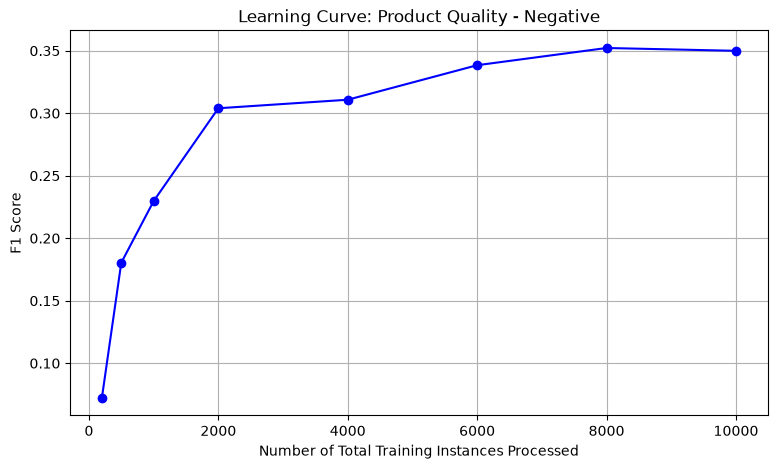

Total authentic training instances for 'Customer Service - Negative': 616


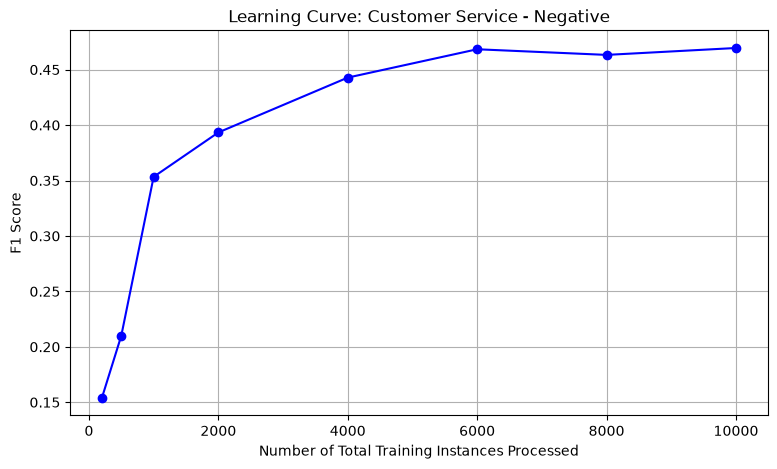

Total authentic training instances for 'Store Operations and Accessibility - Negative': 113


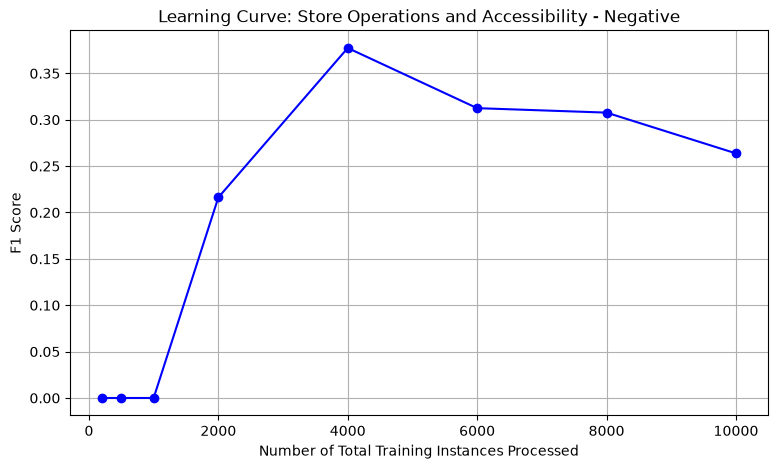

Total authentic training instances for 'Price and Value - Negative': 124


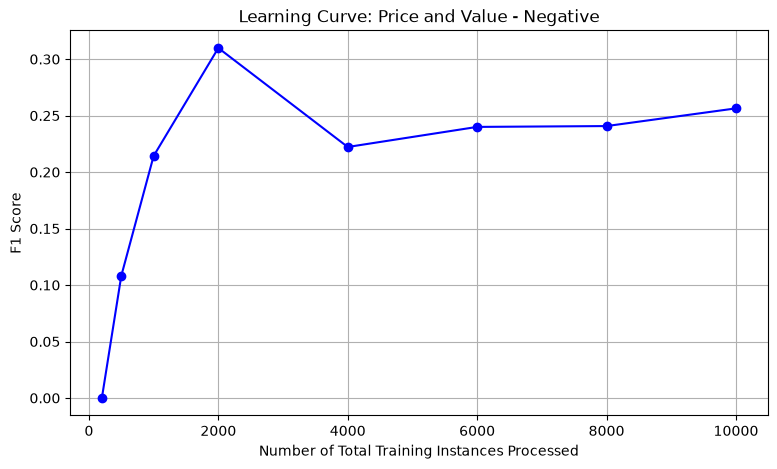

Total authentic training instances for 'Facilities and Amenities - Negative': 157


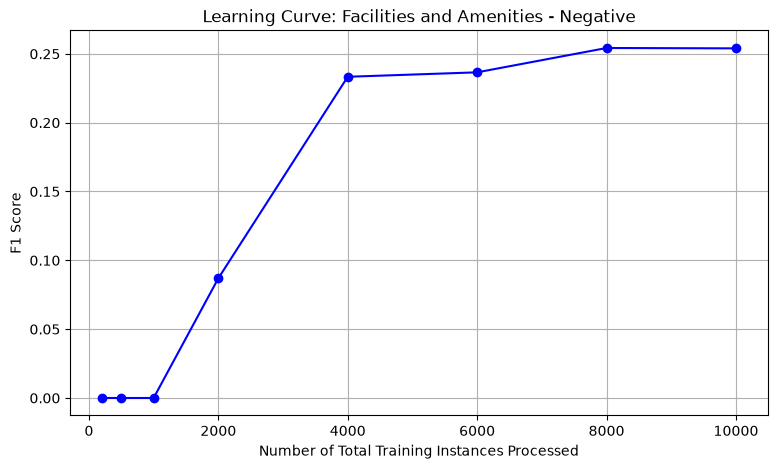

In [33]:
batch_sizes = [200, 500, 1000, 2000, 4000, 6000, 8000, 10000]                                                                                            

plot_learning_curve(df_train, df_val, 'Product Quality - Negative', batch_sizes)
plot_learning_curve(df_train, df_val, 'Customer Service - Negative', batch_sizes)                                                                                                 
plot_learning_curve(df_train, df_val, 'Store Operations and Accessibility - Negative', batch_sizes)                                                       
plot_learning_curve(df_train, df_val, 'Price and Value - Negative', batch_sizes)                                                                          
plot_learning_curve(df_train, df_val, 'Facilities and Amenities - Negative', batch_sizes)  

Store Operations and Accessibility: The F1 score peaks sharply at approximately 0.37 when processing 4,000 instances. Beyond this point, the performance degrades and settles into a lower plateau. Threshold = 4000
Price and Value: This category requires the least data to map semantic boundaries. It peaks rapidly at 2,000 instances with an F1 score near 0.31. Forcing the model to process more data actively harms the classification, causing an immediate drop.: Threshold = 2000
Facilities and Amenities: This class requires massive context to learn. The curve ascends steeply to 4,000, creeps upward at 6,000, and finally hits a hard, mathematically flat plateau at 8,000 instances (F1 ~0.25). Threshold = 5500

In [30]:
total_counts = df_train['TargetAspect'].value_counts()                                                                                                   
                                                                                                                                                            
print("Total Authentic Instances per Aspect in Train Set:")                                                                                              
print(total_counts)   

Total Authentic Instances per Aspect in Train Set:
TargetAspect
Product Quality                       7727
Customer Service                      3228
Ambiance and Atmosphere               2159
Facilities and Amenities              1344
Store Operations and Accessibility     846
Price and Value                        836
Name: count, dtype: int64


In [29]:
# Check the exact counts of authentic negative (1-star and 2-star) reviews for these categories in the Train_Set_70.csv
negative_reviews = df_train[df_train['rating'] <= 2]                                                                                                                                                                                                            
negative_counts = negative_reviews.groupby('TargetAspect').size()                                                                                                                                                                                                                                              
print("Authentic Negative Instances (1-star & 2-star) in Train Set:")                                                                                    
print(negative_counts)       

Authentic Negative Instances (1-star & 2-star) in Train Set:
TargetAspect
Ambiance and Atmosphere               112
Customer Service                      616
Facilities and Amenities              157
Price and Value                       124
Product Quality                       836
Store Operations and Accessibility    113
dtype: int64
